In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/federated_models/

accuracy_initial_vs_final.png  cross_eval_accuracy.png	model_A.h5  model_B.h5


In [ ]:
from tensorflow.keras.models import load_model

model_A = load_model("/content/drive/MyDrive/federated_models/model_A.h5")
model_B = load_model("/content/drive/MyDrive/federated_models/model_B.h5")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

test_gen_A = datagen.flow_from_directory(
    "/content/drive/MyDrive/my_processed_data/test",
    target_size=(224,224),
    color_mode="grayscale",

    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_gen_B = datagen.flow_from_directory(
    "/content/drive/MyDrive/test",
    target_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.
Found 1172 images belonging to 2 classes.


In [ ]:
print("Model A on Dataset A")
model_A.evaluate(test_gen_A)

print("Model B on Dataset B")
model_B.evaluate(test_gen_B)

Model A on Dataset A
 7/20 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.3987 - loss: 2.6926

KeyboardInterrupt: 

In [ ]:
print("Model A on Dataset B")
model_A.evaluate(test_gen_B)

print("Model B on Dataset A")
model_B.evaluate(test_gen_A)

Model A on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9718 - loss: 0.0681
Model B on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9087 - loss: 0.2149


[0.2148955911397934, 0.9086538553237915]

In [ ]:
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
weights_A = model_A.get_weights()
weights_B = model_B.get_weights()

In [ ]:
import numpy as np

nA = 624
nB = 1172

total = nA + nB

weights_A = model_A.get_weights()
weights_B = model_B.get_weights()

avg_weights = []

for wA, wB in zip(weights_A, weights_B):
    avg_weights.append((nA * wA + nB * wB) / total)

global_model = create_model()
global_model.set_weights(avg_weights)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
global_model = create_model()
global_model.set_weights(avg_weights)

In [ ]:
print("Global Model on Dataset A")
global_model.evaluate(test_gen_A)

print("Global Model on Dataset B")
global_model.evaluate(test_gen_B)

Global Model on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 312s 16s/step - accuracy: 0.4904 - loss: 0.6721
Global Model on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 488s 14s/step - accuracy: 0.5179 - loss: 0.6574


[0.657438337802887, 0.5179181098937988]

In [ ]:
model_A.set_weights(global_model.get_weights())
model_B.set_weights(global_model.get_weights())

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen_A = datagen.flow_from_directory(
    "/content/drive/MyDrive/my_processed_data/train",
    target_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

train_gen_B = datagen.flow_from_directory(
    "/content/drive/MyDrive/train",
    target_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.
Found 4684 images belonging to 2 classes.


In [ ]:
model_A.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_A.fit(train_gen_A, epochs=20)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 747s 5s/step - accuracy: 0.9406 - loss: 0.1539
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 140ms/step - accuracy: 0.9641 - loss: 0.0989
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.9664 - loss: 0.0908
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.9699 - loss: 0.0779
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - accuracy: 0.9780 - loss: 0.0669
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - accuracy: 0.9801 - loss: 0.0645
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9785 - loss: 0.0595
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.9803 - loss: 0.0481
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 140ms/step - accuracy: 0.9849 - loss: 0.0438
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.9852 - loss: 0.0426
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.9866 - loss: 0.0364
Epoch 12/20
163/163 ━

In [ ]:
print("Model A on Dataset A")
loss_AA, acc_AA = model_A.evaluate(test_gen_A)


Model A on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.8013 - loss: 1.3165


In [ ]:
model_B.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_B.fit(train_gen_B, epochs=20)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2042s 14s/step - accuracy: 0.9321 - loss: 0.1782
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9400 - loss: 0.1539
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9550 - loss: 0.1295
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - accuracy: 0.9571 - loss: 0.1187
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.9609 - loss: 0.1119
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.9594 - loss: 0.1101
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9671 - loss: 0.1005
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.9648 - loss: 0.0970
Epoch 9/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9684 - loss: 0.0905
Epoch 10/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.9684 - loss: 0.0830
Epoch 11/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9714 - loss: 0.0789
Epoch 12/20
147/147

In [ ]:
print("Model B on Dataset B")
loss_BB, acc_BB = model_B.evaluate(test_gen_B)

Model B on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - accuracy: 0.9573 - loss: 0.1697


In [ ]:
print("Model A on Dataset B")
loss_AB, acc_AB = model_A.evaluate(test_gen_B)

print("Model B on Dataset A")
loss_BA, acc_BA = model_B.evaluate(test_gen_A)

Model A on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.9625 - loss: 0.1139
Model B on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9535 - loss: 0.1197


In [ ]:
weights_A_1 = model_A.get_weights()
weights_B_1 = model_B.get_weights()

In [ ]:
nA = 624
nB = 1172

total = nA + nB

weights_A = model_A.get_weights()
weights_B = model_B.get_weights()

avg_weights = []

for wA, wB in zip(weights_A_1, weights_B_1):
    avg_weights.append((nA * wA + nB * wB) / total)



In [ ]:
global_model = create_model()
global_model.set_weights(avg_weights)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Reset before each evaluation
test_gen_A.reset()
test_gen_B.reset()

In [ ]:
print("Global Model on Dataset A")
global_model.evaluate(test_gen_A)

print("Global Model on Dataset B")
global_model.evaluate(test_gen_B)

Global Model on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9103 - loss: 0.2382
Global Model on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.9633 - loss: 0.0966


[0.09664344787597656, 0.9633105993270874]

**Checking Models individually with final Updated weights**

In [ ]:
model_A.set_weights(global_model.get_weights())
model_B.set_weights(global_model.get_weights())

In [ ]:
print("Model A on Dataset A")
model_A.evaluate(test_gen_A)

print("Model B on Dataset B")
model_B.evaluate(test_gen_B)

Model A on Dataset A
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9103 - loss: 0.2382
Model B on Dataset B
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.9633 - loss: 0.0966


[0.09664344787597656, 0.9633105993270874]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─────────────────────────────────────────────
# DATA FROM NOTEBOOK OUTPUTS
# ─────────────────────────────────────────────

# ── Initial models (before FL) ──
init_acc = {
    "Model A on Dataset A": 0.7644,
    "Model A on Dataset B": 0.9718,
    "Model B on Dataset A": 0.9087,
    "Model B on Dataset B": 0.9309,
}

init_loss = {
    "Model A on Dataset A": 1.1881,
    "Model A on Dataset B": 0.0681,
    "Model B on Dataset A": 0.2149,
    "Model B on Dataset B": 0.1580,
}

# ── After FL (final round 2 global model) ──
final_acc = {
    "Model A (FL) on Dataset A": 0.8910,
    "Model A (FL) on Dataset B": 0.9804,
    "Model B (FL) on Dataset A": 0.9151,
    "Model B (FL) on Dataset B": 0.9650,
}

final_loss = {
    "Model A (FL) on Dataset A": 0.2760,
    "Model A (FL) on Dataset B": 0.0661,
    "Model B (FL) on Dataset A": 0.2129,
    "Model B (FL) on Dataset B": 0.1741,
}

# ─────────────────────────────────────────────
# COLOR PALETTE
# ─────────────────────────────────────────────
C_A_INIT  = "#4C72B0"   # Model A initial – blue
C_B_INIT  = "#DD8452"   # Model B initial – orange
C_A_FL    = "#55A868"   # Model A after FL – green
C_B_FL    = "#C44E52"   # Model B after FL – red


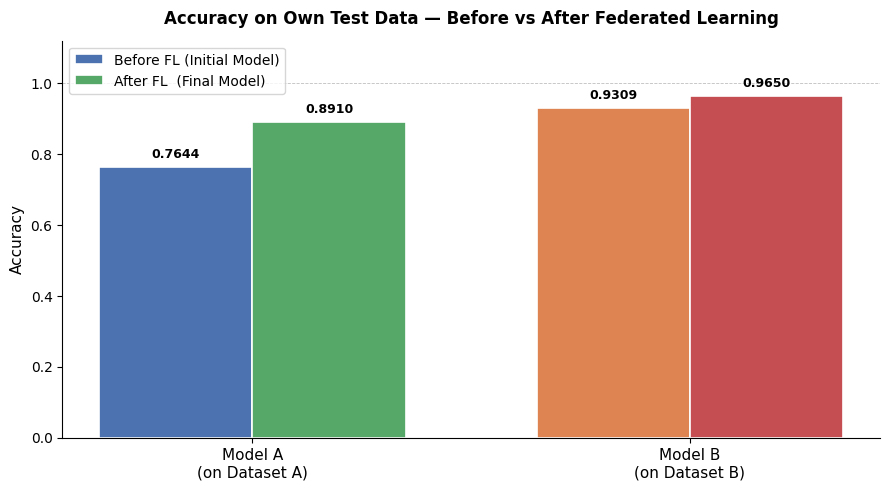

Saved: graph1_own_test_accuracy.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

models     = ["Model A\n(on Dataset A)", "Model B\n(on Dataset B)"]
acc_before = [init_acc["Model A on Dataset A"],  init_acc["Model B on Dataset B"]]
acc_after  = [final_acc["Model A (FL) on Dataset A"], final_acc["Model B (FL) on Dataset B"]]

x   = np.arange(len(models))
w   = 0.35

b1 = ax.bar(x - w/2, acc_before, w, label="Before FL (Initial Model)", color=[C_A_INIT, C_B_INIT], edgecolor="white", linewidth=1.2)
b2 = ax.bar(x + w/2, acc_after,  w, label="After FL  (Final Model)",   color=[C_A_FL,   C_B_FL],   edgecolor="white", linewidth=1.2)

for bar in list(b1) + list(b2):
    ax.annotate(f"{bar.get_height():.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy on Own Test Data — Before vs After Federated Learning", fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("graph1_own_test_accuracy.png", dpi=150)
plt.show()
print("Saved: graph1_own_test_accuracy.png")



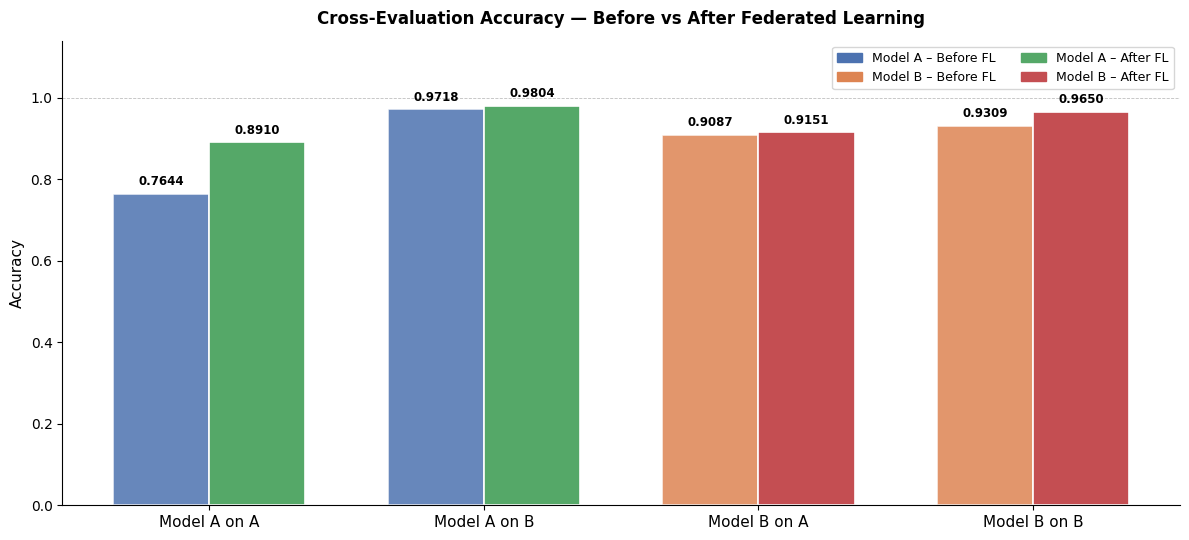

Saved: graph3_cross_eval_accuracy.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.5))

categories  = ["A on A", "A on B", "B on A", "B on B"]
before_vals = [
    init_acc["Model A on Dataset A"],
    init_acc["Model A on Dataset B"],
    init_acc["Model B on Dataset A"],
    init_acc["Model B on Dataset B"],
]
after_vals = [
    final_acc["Model A (FL) on Dataset A"],
    final_acc["Model A (FL) on Dataset B"],
    final_acc["Model B (FL) on Dataset A"],
    final_acc["Model B (FL) on Dataset B"],
]

x2 = np.arange(len(categories))
colors_before = [C_A_INIT, C_A_INIT, C_B_INIT, C_B_INIT]
colors_after  = [C_A_FL,   C_A_FL,   C_B_FL,   C_B_FL]

b1 = ax.bar(x2 - w/2, before_vals, w, label="Before FL", color=colors_before, edgecolor="white", linewidth=1.2, alpha=0.85)
b2 = ax.bar(x2 + w/2, after_vals,  w, label="After FL",  color=colors_after,  edgecolor="white", linewidth=1.2)

for bar in list(b1) + list(b2):
    ax.annotate(f"{bar.get_height():.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x2)
ax.set_xticklabels([f"Model {c}" for c in categories], fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Cross-Evaluation Accuracy — Before vs After Federated Learning", fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 1.14)
ax.axhline(1.0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)

# Custom legend
patch_A_i = mpatches.Patch(color=C_A_INIT, label="Model A – Before FL")
patch_B_i = mpatches.Patch(color=C_B_INIT, label="Model B – Before FL")
patch_A_f = mpatches.Patch(color=C_A_FL,   label="Model A – After FL")
patch_B_f = mpatches.Patch(color=C_B_FL,   label="Model B – After FL")
ax.legend(handles=[patch_A_i, patch_B_i, patch_A_f, patch_B_f], fontsize=9, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("graph3_cross_eval_accuracy.png", dpi=150)
plt.show()
print("Saved: graph3_cross_eval_accuracy.png")

